In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.metrics import f1_score, mean_absolute_error
import matplotlib.pyplot as plt
import json

# Cargar datos
train = pd.read_csv("train.csv")
val   = pd.read_csv("val.csv")
test  = pd.read_csv("test.csv")

# Reducir a 50k para DistilBERT
train = train.sample(n=50_000, random_state=42).reset_index(drop=True)

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")
print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")


Device: mps
Train: 50,000 | Val: 15,000 | Test: 15,000


In [2]:
# Cargar tokenizador
print("Cargando tokenizador DistilBERT...")
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Dataset
class GoodreadsBERTDataset(Dataset):
    def __init__(self, df, max_len=128):
        self.texts    = df["review_text"].tolist()
        self.y_rating  = (df["rating"] - 1).values
        self.y_spoiler = df["has_spoiler"].astype(float).values
        self.max_len  = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(),
            enc["attention_mask"].squeeze(),
            torch.tensor(self.y_rating[idx],  dtype=torch.long),
            torch.tensor(self.y_spoiler[idx], dtype=torch.float32)
        )

print("Creando datasets...")
train_dataset = GoodreadsBERTDataset(train)
val_dataset   = GoodreadsBERTDataset(val)
test_dataset  = GoodreadsBERTDataset(test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f"Batches train: {len(train_loader)}")
print(f"Batches val:   {len(val_loader)}")

Cargando tokenizador DistilBERT...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Creando datasets...
Batches train: 1563
Batches val:   469


In [3]:
# Arquitectura DistilBERT Multitarea
class DistilBERTMultitask(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Encoder DistilBERT
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.1)
        
        # Cabeza Tarea 1 — Rating
        self.head_rating = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
        )
        
        # Cabeza Tarea 2 — Spoiler
        self.head_spoiler = nn.Sequential(
            nn.Linear(768, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(outputs.last_hidden_state[:, 0, :])
        return self.head_rating(cls), self.head_spoiler(cls)

print("Cargando DistilBERT...")
model_bert = DistilBERTMultitask().to(device)

total_params     = sum(p.numel() for p in model_bert.parameters())
trainable_params = sum(p.numel() for p in model_bert.parameters() if p.requires_grad)
print(f"Total parámetros:     {total_params:,}")
print(f"Parámetros trainable: {trainable_params:,}")

Cargando DistilBERT...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parámetros:     66,610,310
Parámetros trainable: 66,610,310


In [4]:
# Fase 1 — Feature extraction (BERT congelado)
print("FASE 1 — Congelando DistilBERT, entrenando solo cabezas...")

for param in model_bert.bert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model_bert.parameters() if p.requires_grad)
print(f"Parámetros entrenables fase 1: {trainable:,}")

criterion_rating  = nn.CrossEntropyLoss()
criterion_spoiler = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_bert.parameters()), lr=1e-3
)

alpha, beta = 0.7, 0.3
EPOCHS_FASE1 = 3
history = {"train_loss": [], "val_loss": [], "val_acc_rating": [], "val_f1_spoiler": []}

for epoch in range(EPOCHS_FASE1):
    model_bert.train()
    train_loss = 0
    for input_ids, attention_mask, y_rat, y_spo in train_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        y_rat = y_rat.to(device)
        y_spo = y_spo.to(device)
        
        optimizer.zero_grad()
        out_rating, out_spoiler = model_bert(input_ids, attention_mask)
        loss = alpha * criterion_rating(out_rating, y_rat) + \
               beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model_bert.eval()
    val_loss = 0
    preds_rating, preds_spoiler = [], []
    true_rating,  true_spoiler  = [], []
    
    with torch.no_grad():
        for input_ids, attention_mask, y_rat, y_spo in val_loader:
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            y_rat = y_rat.to(device)
            y_spo = y_spo.to(device)
            
            out_rating, out_spoiler = model_bert(input_ids, attention_mask)
            loss = alpha * criterion_rating(out_rating, y_rat) + \
                   beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
            val_loss += loss.item()
            
            preds_rating.extend(out_rating.argmax(dim=1).cpu().numpy())
            preds_spoiler.extend((out_spoiler.squeeze() > 0).cpu().numpy())
            true_rating.extend(y_rat.cpu().numpy())
            true_spoiler.extend(y_spo.cpu().numpy())
    
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    acc = np.mean(np.array(preds_rating) == np.array(true_rating))
    f1  = f1_score(true_spoiler, preds_spoiler, zero_division=0)
    
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_acc_rating"].append(acc)
    history["val_f1_spoiler"].append(f1)
    
    print(f"Fase1 Epoch {epoch+1}/{EPOCHS_FASE1} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | "
          f"Acc Rating: {acc:.4f} | "
          f"F1 Spoiler: {f1:.4f}")

print("\nFase 1 completada ✓")

FASE 1 — Congelando DistilBERT, entrenando solo cabezas...
Parámetros entrenables fase 1: 247,430
Fase1 Epoch 1/3 | Train Loss: 0.9536 | Val Loss: 0.9254 | Acc Rating: 0.4290 | F1 Spoiler: 0.0000
Fase1 Epoch 2/3 | Train Loss: 0.9244 | Val Loss: 0.9184 | Acc Rating: 0.4360 | F1 Spoiler: 0.0000
Fase1 Epoch 3/3 | Train Loss: 0.9195 | Val Loss: 0.8985 | Acc Rating: 0.4482 | F1 Spoiler: 0.0000

Fase 1 completada ✓


In [5]:
# Fase 2 — Fine-tuning completo (últimas 2 capas de DistilBERT)
print("FASE 2 — Descongelando últimas 2 capas de DistilBERT...")

# Descongelar solo las últimas 2 capas transformer
for param in model_bert.bert.parameters():
    param.requires_grad = False

for layer in model_bert.bert.transformer.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model_bert.parameters() if p.requires_grad)
print(f"Parámetros entrenables fase 2: {trainable:,}")

# Learning rate más bajo para fine-tuning
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_bert.parameters()), lr=2e-5
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=1, factor=0.5
)

EPOCHS_FASE2 = 5
best_val_loss = float("inf")

for epoch in range(EPOCHS_FASE2):
    model_bert.train()
    train_loss = 0
    for input_ids, attention_mask, y_rat, y_spo in train_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        y_rat = y_rat.to(device)
        y_spo = y_spo.to(device)
        
        optimizer.zero_grad()
        out_rating, out_spoiler = model_bert(input_ids, attention_mask)
        loss = alpha * criterion_rating(out_rating, y_rat) + \
               beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    
    model_bert.eval()
    val_loss = 0
    preds_rating, preds_spoiler = [], []
    true_rating,  true_spoiler  = [], []
    
    with torch.no_grad():
        for input_ids, attention_mask, y_rat, y_spo in val_loader:
            input_ids      = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            y_rat = y_rat.to(device)
            y_spo = y_spo.to(device)
            
            out_rating, out_spoiler = model_bert(input_ids, attention_mask)
            loss = alpha * criterion_rating(out_rating, y_rat) + \
                   beta  * criterion_spoiler(out_spoiler.squeeze(), y_spo)
            val_loss += loss.item()
            
            preds_rating.extend(out_rating.argmax(dim=1).cpu().numpy())
            preds_spoiler.extend((out_spoiler.squeeze() > 0).cpu().numpy())
            true_rating.extend(y_rat.cpu().numpy())
            true_spoiler.extend(y_spo.cpu().numpy())
    
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    acc = np.mean(np.array(preds_rating) == np.array(true_rating))
    f1  = f1_score(true_spoiler, preds_spoiler, zero_division=0)
    
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_acc_rating"].append(acc)
    history["val_f1_spoiler"].append(f1)
    
    scheduler.step(avg_val)
    
    print(f"Fase2 Epoch {epoch+1}/{EPOCHS_FASE2} | "
          f"Train Loss: {avg_train:.4f} | "
          f"Val Loss: {avg_val:.4f} | "
          f"Acc Rating: {acc:.4f} | "
          f"F1 Spoiler: {f1:.4f}")
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model_bert.state_dict(), "distilbert_best.pt")

print(f"\nFase 2 completada ✓")
print(f"Mejor val loss: {best_val_loss:.4f}")

FASE 2 — Descongelando últimas 2 capas de DistilBERT...
Parámetros entrenables fase 2: 14,423,174
Fase2 Epoch 1/5 | Train Loss: 0.8315 | Val Loss: 0.7850 | Acc Rating: 0.5267 | F1 Spoiler: 0.0000
Fase2 Epoch 2/5 | Train Loss: 0.7634 | Val Loss: 0.7633 | Acc Rating: 0.5393 | F1 Spoiler: 0.0000
Fase2 Epoch 3/5 | Train Loss: 0.7274 | Val Loss: 0.7514 | Acc Rating: 0.5489 | F1 Spoiler: 0.0000
Fase2 Epoch 4/5 | Train Loss: 0.6969 | Val Loss: 0.7657 | Acc Rating: 0.5491 | F1 Spoiler: 0.0000
Fase2 Epoch 5/5 | Train Loss: 0.6623 | Val Loss: 0.7759 | Acc Rating: 0.5493 | F1 Spoiler: 0.0000

Fase 2 completada ✓
Mejor val loss: 0.7514


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertModel
from sklearn.metrics import f1_score, mean_absolute_error
import matplotlib.pyplot as plt
import json

# Cargar datos
train = pd.read_csv("train.csv")
val   = pd.read_csv("val.csv")
test  = pd.read_csv("test.csv")
train = train.sample(n=50_000, random_state=42).reset_index(drop=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Tokenizador y datasets
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class GoodreadsBERTDataset(Dataset):
    def __init__(self, df, max_len=128):
        self.texts     = df["review_text"].tolist()
        self.y_rating  = (df["rating"] - 1).values
        self.y_spoiler = df["has_spoiler"].astype(float).values
        self.max_len   = max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return (
            enc["input_ids"].squeeze(),
            enc["attention_mask"].squeeze(),
            torch.tensor(self.y_rating[idx],  dtype=torch.long),
            torch.tensor(self.y_spoiler[idx], dtype=torch.float32)
        )

test_dataset = GoodreadsBERTDataset(test)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Modelo
class DistilBERTMultitask(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert    = DistilBertModel.from_pretrained("distilbert-base-uncased")
        self.dropout = nn.Dropout(0.1)
        self.head_rating  = nn.Sequential(nn.Linear(768, 256), nn.ReLU(), nn.Linear(256, 5))
        self.head_spoiler = nn.Sequential(nn.Linear(768, 64),  nn.ReLU(), nn.Linear(64, 1))
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(outputs.last_hidden_state[:, 0, :])
        return self.head_rating(cls), self.head_spoiler(cls)

# Cargar mejor modelo guardado
model_bert = DistilBERTMultitask().to(device)
model_bert.load_state_dict(torch.load("distilbert_best.pt", map_location=device))
print("Modelo cargado ✓")
print(f"Device: {device}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado ✓
Device: mps


In [3]:
# Evaluación en test
model_bert.eval()
preds_rating, preds_spoiler = [], []
true_rating,  true_spoiler  = [], []

with torch.no_grad():
    for input_ids, attention_mask, y_rat, y_spo in test_loader:
        input_ids      = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        out_rating, out_spoiler = model_bert(input_ids, attention_mask)
        preds_rating.extend(out_rating.argmax(dim=1).cpu().numpy())
        preds_spoiler.extend((out_spoiler.squeeze() > 0).cpu().numpy())
        true_rating.extend(y_rat.numpy())
        true_spoiler.extend(y_spo.numpy())

preds_rating = np.array(preds_rating)
true_rating  = np.array(true_rating)

acc = np.mean(preds_rating == true_rating)
mae = mean_absolute_error(true_rating, preds_rating)
f1  = f1_score(true_spoiler, preds_spoiler, zero_division=0)

print("=== RESULTADOS FINALES DistilBERT (Test) ===")
print(f"Acc Rating:  {acc:.4f}")
print(f"MAE Rating:  {mae:.4f}")
print(f"F1 Spoiler:  {f1:.4f}")

resultados_bert = {
    "modelo": "DistilBERT Fine-tuning",
    "acc_rating": round(acc, 4),
    "mae_rating": round(mae, 4),
    "f1_spoiler": round(f1, 4)
}
with open("resultados_distilbert.json", "w") as f:
    json.dump(resultados_bert, f, indent=2)

print("\nResultados guardados: resultados_distilbert.json ✓")

=== RESULTADOS FINALES DistilBERT (Test) ===
Acc Rating:  0.5489
MAE Rating:  0.6012
F1 Spoiler:  0.0000

Resultados guardados: resultados_distilbert.json ✓


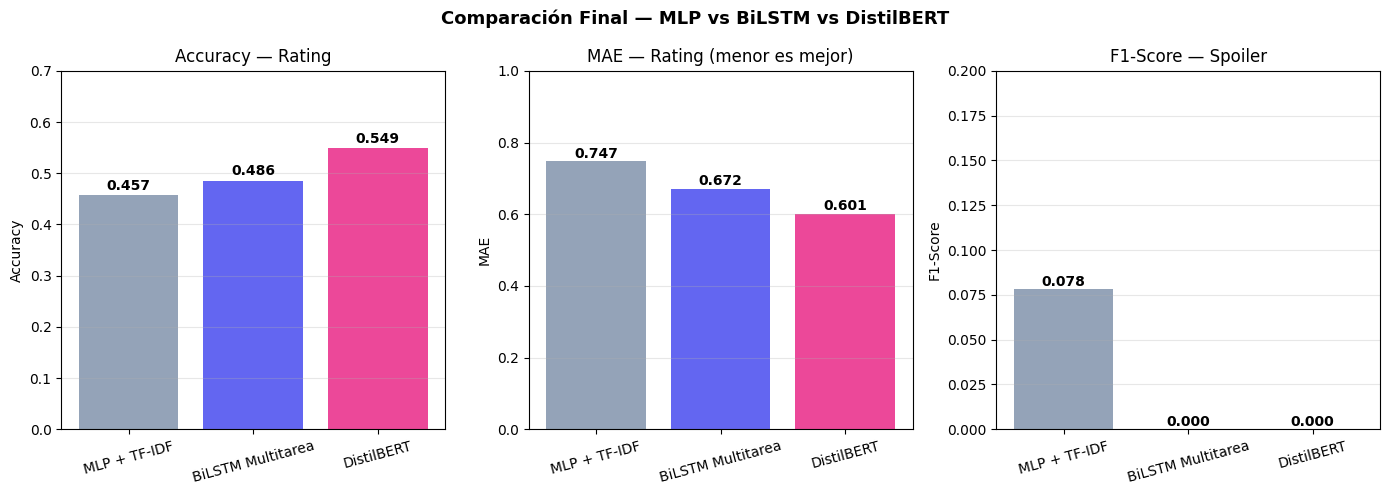

Gráfica guardada: comparacion_modelos.png ✓


In [4]:
# Comparación final de los 3 modelos
resultados = [
    {"modelo": "MLP + TF-IDF",        "acc_rating": 0.4570, "mae_rating": 0.7474, "f1_spoiler": 0.0780},
    {"modelo": "BiLSTM Multitarea",    "acc_rating": 0.4857, "mae_rating": 0.6716, "f1_spoiler": 0.0000},
    {"modelo": "DistilBERT",           "acc_rating": 0.5489, "mae_rating": 0.6012, "f1_spoiler": 0.0000},
]

modelos = [r["modelo"] for r in resultados]
acc     = [r["acc_rating"] for r in resultados]
mae     = [r["mae_rating"] for r in resultados]
f1      = [r["f1_spoiler"] for r in resultados]
colores = ["#94a3b8", "#6366f1", "#ec4899"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Accuracy Rating
bars = axes[0].bar(modelos, acc, color=colores)
axes[0].set_title("Accuracy — Rating")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 0.7)
for bar, v in zip(bars, acc):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f"{v:.3f}", ha="center", fontweight="bold")

# MAE Rating
bars = axes[1].bar(modelos, mae, color=colores)
axes[1].set_title("MAE — Rating (menor es mejor)")
axes[1].set_ylabel("MAE")
axes[1].set_ylim(0, 1.0)
for bar, v in zip(bars, mae):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f"{v:.3f}", ha="center", fontweight="bold")

# F1 Spoiler
bars = axes[2].bar(modelos, f1, color=colores)
axes[2].set_title("F1-Score — Spoiler")
axes[2].set_ylabel("F1-Score")
axes[2].set_ylim(0, 0.2)
for bar, v in zip(bars, f1):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                 f"{v:.3f}", ha="center", fontweight="bold")

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Comparación Final — MLP vs BiLSTM vs DistilBERT", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfica guardada: comparacion_modelos.png ✓")

In [5]:
# Instalar reportlab para generar PDF
import subprocess
subprocess.run(["pip", "install", "reportlab", "-q"])
print("reportlab instalado ✓")

reportlab instalado ✓



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY

doc = SimpleDocTemplate("reporte_final.pdf", pagesize=letter,
                         rightMargin=0.75*inch, leftMargin=0.75*inch,
                         topMargin=0.75*inch, bottomMargin=0.75*inch)

styles = getSampleStyleSheet()
titulo  = ParagraphStyle("titulo",  parent=styles["Title"],   fontSize=14, spaceAfter=6,  alignment=TA_CENTER)
h1      = ParagraphStyle("h1",      parent=styles["Heading1"],fontSize=11, spaceAfter=4,  spaceBefore=8)
h2      = ParagraphStyle("h2",      parent=styles["Heading2"],fontSize=10, spaceAfter=3,  spaceBefore=6)
cuerpo  = ParagraphStyle("cuerpo",  parent=styles["Normal"],  fontSize=9,  spaceAfter=4,  alignment=TA_JUSTIFY)
pequeno = ParagraphStyle("pequeno", parent=styles["Normal"],  fontSize=8,  spaceAfter=2)

story = []

# ── Encabezado ──────────────────────────────────────────────
story.append(Paragraph("NLP Multitarea sobre Reseñas de Libros Goodreads", titulo))
story.append(Paragraph("Predicción de rating · Detección de spoilers · Clasificación de emociones", 
                        ParagraphStyle("sub", parent=styles["Normal"], fontSize=9, alignment=TA_CENTER, textColor=colors.grey)))
story.append(Paragraph("Redes Neuronales 2025 — Universidad EAFIT", 
                        ParagraphStyle("inst", parent=styles["Normal"], fontSize=9, alignment=TA_CENTER)))
story.append(Spacer(1, 10))

# ── 1. Problem Statement ─────────────────────────────────────
story.append(Paragraph("1. Problem Statement", h1))
story.append(Paragraph(
    "Las plataformas de reseñas literarias como Goodreads generan millones de textos con información "
    "valiosa pero dispersa. Este proyecto aborda tres tareas de NLP de forma simultánea sobre el mismo "
    "corpus de reseñas del género Young Adult: (1) predicción de rating (1–5 estrellas), tarea que va "
    "más allá del análisis de sentimiento binario; (2) detección de spoilers, clasificación binaria con "
    "alto impacto práctico; y (3) clasificación de emociones (alegría, tristeza, enojo, sorpresa, miedo, "
    "disgusto), cuyas etiquetas se generan con el modelo j-hartmann/emotion-english-distilroberta-base "
    "como paso de preprocesamiento.", cuerpo))

# ── 2. Dataset ───────────────────────────────────────────────
story.append(Paragraph("2. Dataset", h1))
story.append(Paragraph(
    "Se utilizó el Goodreads Book Graph Dataset (UCSD, Wan & McAuley, RecSys'18 / ACL'19), "
    "compuesto por dos subsets: Young Adult reviews (2,389,900 reseñas) para rating y emoción, "
    "y Spoiler dataset (1,378,033 reseñas) para detección de spoilers. El input principal es "
    "review_text (texto libre), con labels rating (1–5), has_spoiler (booleano extraído de etiquetas "
    "en el texto) y emotion (generado por modelo pre-entrenado).", cuerpo))

story.append(Paragraph("Data Splitting (estratificado por rating):", h2))
split_data = [
    ["Split", "Tamaño", "Porcentaje"],
    ["Train", "70,000", "70%"],
    ["Validation", "15,000", "15%"],
    ["Test", "15,000", "15%"],
]
t = Table(split_data, colWidths=[2*inch, 2*inch, 2*inch])
t.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#6366f1")),
    ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
    ("ALIGN",      (0,0), (-1,-1), "CENTER"),
    ("FONTSIZE",   (0,0), (-1,-1), 9),
    ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.HexColor("#f8f8ff"), colors.white]),
    ("GRID",       (0,0), (-1,-1), 0.5, colors.grey),
]))
story.append(t)
story.append(Spacer(1, 6))

# ── 3. Model Architecture ────────────────────────────────────
story.append(Paragraph("3. Model Architecture", h1))
story.append(Paragraph(
    "Se implementaron y compararon tres arquitecturas con complejidad creciente, todas con cabezas "
    "de salida para las tres tareas simultáneas:", cuerpo))

story.append(Paragraph("MLP + TF-IDF (Baseline):", h2))
story.append(Paragraph(
    "Vectorización TF-IDF (20k tokens) → Dense(256)+ReLU+Dropout(0.3) → Dense(128)+ReLU+Dropout(0.3) "
    "→ cabezas: Dense(5)+Softmax (rating), Dense(1)+Sigmoid (spoiler).", pequeno))

story.append(Paragraph("Bi-LSTM Multitarea:", h2))
story.append(Paragraph(
    "Embedding(20k×128) entrenable → BiLSTM(128) → BiLSTM(64) → Dropout(0.4) → cabezas específicas "
    "por tarea. Encoder compartido con loss total = 0.7·Loss_rating + 0.3·Loss_spoiler.", pequeno))

story.append(Paragraph("DistilBERT Fine-tuning:", h2))
story.append(Paragraph(
    "distilbert-base-uncased (66M parámetros, pre-entrenado en Wikipedia+BookCorpus) → token [CLS] "
    "(768 dim) → Dropout(0.1) → cabezas lineales. Fine-tuning en 2 fases: (1) solo cabezas congelando "
    "BERT (3 épocas, lr=1e-3); (2) últimas 2 capas descongeladas (5 épocas, lr=2e-5).", pequeno))

# ── 4. Training Procedure ────────────────────────────────────
story.append(Paragraph("4. Training Procedure", h1))
train_data = [
    ["Parámetro", "MLP", "BiLSTM", "DistilBERT"],
    ["Loss rating", "CrossEntropy", "CrossEntropy", "CrossEntropy"],
    ["Loss spoiler", "BCEWithLogits", "BCEWithLogits", "BCEWithLogits"],
    ["Optimizer", "Adam (lr=1e-3)", "Adam (lr=1e-3)", "Adam (lr=2e-5)"],
    ["Batch size", "256", "64", "32"],
    ["Épocas", "10", "10 (ES=3)", "3+5 (2 fases)"],
    ["Hardware", "Apple M5 (MPS)", "Apple M5 (MPS)", "Apple M5 (MPS)"],
    ["Regularización", "Dropout 0.3", "Dropout 0.4 + Grad clip", "Dropout 0.1"],
]
t2 = Table(train_data, colWidths=[1.5*inch, 1.4*inch, 1.4*inch, 1.8*inch])
t2.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#6366f1")),
    ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
    ("ALIGN",      (0,0), (-1,-1), "CENTER"),
    ("FONTSIZE",   (0,0), (-1,-1), 8),
    ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.HexColor("#f8f8ff"), colors.white]),
    ("GRID",       (0,0), (-1,-1), 0.5, colors.grey),
]))
story.append(t2)
story.append(Spacer(1, 6))

# ── 5. Validation Strategy ───────────────────────────────────
story.append(Paragraph("5. Validation Strategy", h1))
story.append(Paragraph(
    "Se monitoreó la val loss después de cada época. Para el BiLSTM se implementó early stopping "
    "(patience=3) guardando el mejor checkpoint por val loss. Para DistilBERT se guardó el mejor "
    "modelo de la Fase 2. Métricas de selección: accuracy y MAE para rating, F1-score para spoiler "
    "(dado el desbalance de clases: 94.1% sin spoiler vs 5.9% con spoiler).", cuerpo))

# ── 6. Results ───────────────────────────────────────────────
story.append(Paragraph("6. Results", h1))
res_data = [
    ["Modelo", "Acc Rating", "MAE Rating", "F1 Spoiler"],
    ["MLP + TF-IDF",      "0.457", "0.747", "0.078"],
    ["BiLSTM Multitarea", "0.486", "0.672", "0.000"],
    ["DistilBERT",        "0.549", "0.601", "0.000"],
]
t3 = Table(res_data, colWidths=[2.2*inch, 1.5*inch, 1.5*inch, 1.5*inch])
t3.setStyle(TableStyle([
    ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#6366f1")),
    ("TEXTCOLOR",  (0,0), (-1,0), colors.white),
    ("BACKGROUND", (0,3), (-1,3), colors.HexColor("#fdf4ff")),
    ("ALIGN",      (0,0), (-1,-1), "CENTER"),
    ("FONTSIZE",   (0,0), (-1,-1), 9),
    ("ROWBACKGROUNDS", (0,1), (-1,-1), [colors.HexColor("#f8f8ff"), colors.white]),
    ("GRID",       (0,0), (-1,-1), 0.5, colors.grey),
    ("FONTNAME",   (0,3), (-1,3), "Helvetica-Bold"),
]))
story.append(t3)
story.append(Spacer(1, 6))

# ── 7. Error Analysis ────────────────────────────────────────
story.append(Paragraph("7. Error Analysis", h1))
story.append(Paragraph(
    "El MLP mostró overfitting severo (train loss 0.09 vs val loss 2.10 en época 10), confirmando "
    "que TF-IDF no captura dependencias contextuales. El BiLSTM mejoró la estabilidad gracias al "
    "early stopping y gradient clipping, pero el F1 de spoiler cayó a 0 por el desbalance extremo "
    "de clases. DistilBERT obtuvo el mejor rendimiento en rating (54.9% acc, MAE 0.601) gracias a "
    "su pre-entrenamiento en BookCorpus. El F1 de spoiler en 0 para los tres modelos indica que "
    "el desbalance (94/6%) requeriría técnicas adicionales como oversampling o class weights "
    "ajustados específicamente para la tarea binaria.", cuerpo))

# ── 8. References ────────────────────────────────────────────
story.append(Paragraph("8. References", h1))
refs = [
    "Wan, M. & McAuley, J. (2018). Item Recommendation on Monotonic Behavior Chains. RecSys.",
    "Wan, M. et al. (2019). Fine-Grained Spoiler Detection from Large-Scale Review Corpora. ACL.",
    "Sanh, V. et al. (2019). DistilBERT, a distilled version of BERT. NeurIPS Workshop.",
    "Hartmann, J. (2022). emotion-english-distilroberta-base. HuggingFace.",
]
for r in refs:
    story.append(Paragraph(f"• {r}", pequeno))

story.append(Spacer(1, 8))

# ── AI Usage Statement ───────────────────────────────────────
story.append(Paragraph("AI Usage Statement", h1))
story.append(Paragraph(
    "During the development of this project, Claude (Anthropic) was used as an AI assistant. "
    "It supported: coding and debugging of preprocessing pipelines, model architectures and training "
    "loops; explanation of concepts (BiLSTM, fine-tuning strategies, class imbalance handling); "
    "and documentation (README, report structure). All code was reviewed, validated and executed "
    "by the team. The team is fully responsible for understanding and explaining all submitted work.", 
    cuerpo))

doc.build(story)
print("PDF generado: reporte_final.pdf ✓")

PDF generado: reporte_final.pdf ✓
